In [9]:
import numpy as np

def solve_fvm_2d():
    # --- 1. Problem Setup ---
    n = 3               # Number of control volumes (3x3 grid)
    L = 1.0             # Domain length (m)
    dx = L / n
    dy = L / n
    
    # Physical Properties
    rho = 1.0           # Density
    gamma = 0.1         # Diffusion coefficient
    u = 2.0             # Velocity in x
    v = 0.0             # Velocity in y
    
    # Boundary Conditions
    phi_left = 100.0
    phi_right = 0.0
    # Top and Bottom are adiabatic (zero gradient)
    
    # --- 2. Calculate FVM Fluxes ---
    # Advection flux (F = rho * u * Area)
    F = rho * u * dy
    # Diffusion conductance (D = gamma * Area / distance)
    D = gamma * dy / dx
    
    # Coefficients based on Upwind Scheme (for u > 0)
    aW = D + F
    aE = D
    aS = D
    aN = D
    aP = aW + aE + aS + aN
    
    # --- 3. Initialize Solution Array ---
    # We use a 2D array for the 3x3 grid
    phi = np.zeros((n, n)) 
    
    # --- 4. Gauss-Seidel Solver ---
    max_iter = 1000
    tolerance = 1e-6
    
    print(f"Starting Gauss-Seidel for {n}x{n} grid...")
    
    for iteration in range(max_iter):
        phi_old = phi.copy()
        
        # Loop through each control volume
        for i in range(n):     # x-direction (0=West, 2=East)
            for j in range(n): # y-direction (0=South, 2=North)
                
                # Identify Neighbors and handle Boundary Conditions
                # West Neighbor
                val_W = phi[i-1, j] if i > 0 else phi_left
                
                # East Neighbor
                val_E = phi[i+1, j] if i < n-1 else phi_right
                
                # South Neighbor (Zero gradient: if at boundary, use self)
                val_S = phi[i, j-1] if j > 0 else phi[i, j]
                
                # North Neighbor (Zero gradient: if at boundary, use self)
                val_N = phi[i, j+1] if j < n-1 else phi[i, j]
                
                # Apply discretized equation: phi_P = (Sum a_nb * phi_nb) / a_P
                # Note: For adiabatic boundaries, the coefficient aS or aN 
                # effectively cancels out because phi_nb = phi_P
                
                numerator = (aW * val_W) + (aE * val_E)
                
                # Add Y-direction flux only if not at adiabatic boundary
                if j > 0: numerator += aS * val_S
                if j < n-1: numerator += aN * val_N
                
                # Adjust aP for adiabatic boundaries (flux is zero)
                current_aP = aP
                if j == 0: current_aP -= aS
                if j == n-1: current_aP -= aN
                
                phi[i, j] = numerator / current_aP
        
        # Check convergence
        error = np.max(np.abs(phi - phi_old))
        if error < tolerance:
            print(f"Converged in {iteration} iterations.")
            break
            
    return phi

solution = solve_fvm_2d()

print("\nFinal Phi Distribution (3x3 Grid):")
print("Row indices represent Y (bottom to top), Column indices represent X (left to right)")
print(np.flipud(solution.T))



Starting Gauss-Seidel for 3x3 grid...
Converged in 15 iterations.

Final Phi Distribution (3x3 Grid):
Row indices represent Y (bottom to top), Column indices represent X (left to right)
[[99.80697737 98.32713747 86.98169852]
 [99.80697733 98.32713738 86.98169843]
 [99.80697728 98.32713728 86.98169832]]


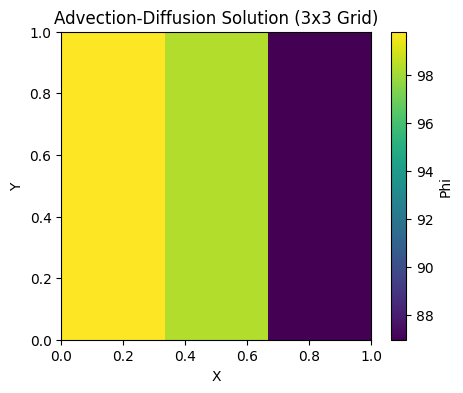

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 4))
plt.imshow(np.flipud(solution.T), cmap='viridis', aspect='auto',
           extent=[0, 1, 0, 1], origin='lower')
plt.colorbar(label='Phi')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Advection-Diffusion Solution (3x3 Grid)')
plt.show()

In [8]:
import numpy as np

# =============================================================================
# Parameters
# =============================================================================
rho = 1.0          # density [kg/m^3]
Gamma = 0.01       # diffusion coefficient [kg/(m·s)]
u = 2.0            # velocity in x-direction [m/s]
v = 0.0            # velocity in y-direction [m/s]

# Domain size [m]
Lx = 1.0
Ly = 1.0

# Grid (nx × ny) nodes
nx = 5
ny = 5

# Grid spacing
dx = Lx / (nx - 1)
dy = Ly / (ny - 1)

# Advective mass fluxes (only horizontal flow)
# Face area for east/west faces = Δy (per unit depth)
F_e = rho * u * dy   # = 0.4
F_w = rho * u * dy   # = 0.4
# North/south fluxes are zero because v = 0
F_n = 0.0
F_s = 0.0

# Diffusion conductances
D_e = Gamma * dy / dx  
D_w = Gamma * dy / dx   
D_n = Gamma * dx / dy   
D_s = Gamma * dx / dy   

# Upwind scheme coefficients (u > 0, v = 0)
a_W = D_w + F_w   
a_E = D_e         
a_S = D_s         
a_N = D_n         
a_P = a_W + a_E + a_S + a_N  

# Boundary values
phi_left = 100.0
phi_right = 0.0

# =============================================================================
# Initialization
# =============================================================================
# Create array for phi, indices: i = 0..nx-1 (x-direction), j = 0..ny-1 (y-direction)
phi = np.zeros((nx, ny))

# Set Dirichlet boundaries
phi[0, :] = phi_left          # left boundary (i=0)
phi[nx-1, :] = phi_right      # right boundary (i=nx-1)

# =============================================================================
# Gauss–Seidel iteration
# =============================================================================
max_iter = 10000
tolerance = 1e-6
residual = 1.0
iter_count = 0

while residual > tolerance and iter_count < max_iter:
    residual = 0.0
    phi_old = phi.copy()
    
    # Loop over all unknown nodes: i = 1 .. nx-2, j = 0 .. ny-1
    for i in range(1, nx-1):
        for j in range(ny):
            # Effective central coefficient (modify for zero-gradient at y boundaries)
            if j == 0:          # bottom boundary: zero gradient
                a_P_eff = a_P - a_S
                sum_neighbors = 0.0
                # West neighbor (i-1) – could be known (i=1) or unknown (i>1)
                if i == 1:
                    sum_neighbors += a_W * phi_left
                else:
                    sum_neighbors += a_W * phi[i-1, j]
                # East neighbor (i+1) – could be known (i=nx-2) or unknown
                if i == nx-2:
                    sum_neighbors += a_E * phi_right
                else:
                    sum_neighbors += a_E * phi[i+1, j]
                # South neighbor is ghost – term absorbed, no contribution
                # North neighbor (j+1) – always unknown (j=0, j+1=1)
                sum_neighbors += a_N * phi[i, j+1]
                
            elif j == ny-1:     # top boundary: zero gradient
                a_P_eff = a_P - a_N
                sum_neighbors = 0.0
                if i == 1:
                    sum_neighbors += a_W * phi_left
                else:
                    sum_neighbors += a_W * phi[i-1, j]
                if i == nx-2:
                    sum_neighbors += a_E * phi_right
                else:
                    sum_neighbors += a_E * phi[i+1, j]
                # South neighbor (j-1)
                sum_neighbors += a_S * phi[i, j-1]
                # North neighbor is ghost – term absorbed
                
            else:               # interior in y
                a_P_eff = a_P
                sum_neighbors = 0.0
                if i == 1:
                    sum_neighbors += a_W * phi_left
                else:
                    sum_neighbors += a_W * phi[i-1, j]
                if i == nx-2:
                    sum_neighbors += a_E * phi_right
                else:
                    sum_neighbors += a_E * phi[i+1, j]
                sum_neighbors += a_S * phi[i, j-1]
                sum_neighbors += a_N * phi[i, j+1]
            
            # Update phi using latest values (Gauss–Seidel)
            phi_new = sum_neighbors / a_P_eff
            residual += abs(phi_new - phi[i, j])
            phi[i, j] = phi_new
    
    # Use maximum change as residual (here sum of absolute changes)
    # Alternatively, compute max norm
    # residual = np.max(np.abs(phi - phi_old))
    # Using sum is fine; we'll keep sum for consistency with typical code.
    residual = np.sum(np.abs(phi - phi_old))
    iter_count += 1

print(f"Converged after {iter_count} iterations, residual = {residual:.2e}\n")

# =============================================================================
# Output results as a table
# =============================================================================


print("Final phi values:")
print(phi)


Converged after 9 iterations, residual = 2.36e-07

Final phi values:
[[100.         100.         100.         100.         100.        ]
 [ 99.99926092  99.99926092  99.99926092  99.99926092  99.99926092]
 [ 99.96156802  99.96156802  99.96156802  99.96156802  99.96156802]
 [ 98.03923017  98.03923018  98.03923018  98.03923018  98.03923018]
 [  0.           0.           0.           0.           0.        ]]


In [12]:
import numpy as np

# =============================================================================
# Parameters
# =============================================================================
rho = 1.0          # density [kg/m^3]
Gamma = 0.01       # diffusion coefficient [kg/(m·s)]
u = 2.0            # velocity in x-direction [m/s]
v = 0.0            # velocity in y-direction [m/s]

# Domain size [m]
Lx = 1.0
Ly = 1.0

# Grid (nx × ny) nodes
nx = 5
ny = 5

# Grid spacing
dx = Lx / (nx - 1)
dy = Ly / (ny - 1)

# Advective mass fluxes (only horizontal flow)
F_e = rho * u * dy   # = 0.4
F_w = rho * u * dy   # = 0.4
F_n = 0.0
F_s = 0.0

# Diffusion conductances
D_e = Gamma * dy / dx
D_w = Gamma * dy / dx
D_n = Gamma * dx / dy
D_s = Gamma * dx / dy

# Upwind scheme coefficients (u > 0, v = 0)
a_W = D_w + F_w
a_E = D_e
a_S = D_s
a_N = D_n
a_P = a_W + a_E + a_S + a_N

# Boundary values
phi_left = 100.0
phi_right = 0.0

# =============================================================================
# Initialization
# =============================================================================
phi = np.zeros((nx, ny))
phi[0, :] = phi_left
phi[nx-1, :] = phi_right

# =============================================================================
# Gauss–Seidel iteration
# =============================================================================
max_iter = 10000
tolerance = 1e-6
residual = 1.0
iter_count = 0

while residual > tolerance and iter_count < max_iter:
    residual = 0.0
    phi_old = phi.copy()
    
    for i in range(1, nx-1):
        for j in range(ny):
            if j == 0:          # bottom boundary: zero gradient
                a_P_eff = a_P - a_S
                sum_neighbors = 0.0
                if i == 1:
                    sum_neighbors += a_W * phi_left
                else:
                    sum_neighbors += a_W * phi[i-1, j]
                if i == nx-2:
                    sum_neighbors += a_E * phi_right
                else:
                    sum_neighbors += a_E * phi[i+1, j]
                sum_neighbors += a_N * phi[i, j+1]
                
            elif j == ny-1:     # top boundary: zero gradient
                a_P_eff = a_P - a_N
                sum_neighbors = 0.0
                if i == 1:
                    sum_neighbors += a_W * phi_left
                else:
                    sum_neighbors += a_W * phi[i-1, j]
                if i == nx-2:
                    sum_neighbors += a_E * phi_right
                else:
                    sum_neighbors += a_E * phi[i+1, j]
                sum_neighbors += a_S * phi[i, j-1]
                
            else:               # interior in y
                a_P_eff = a_P
                sum_neighbors = 0.0
                if i == 1:
                    sum_neighbors += a_W * phi_left
                else:
                    sum_neighbors += a_W * phi[i-1, j]
                if i == nx-2:
                    sum_neighbors += a_E * phi_right
                else:
                    sum_neighbors += a_E * phi[i+1, j]
                sum_neighbors += a_S * phi[i, j-1]
                sum_neighbors += a_N * phi[i, j+1]
            
            phi_new = sum_neighbors / a_P_eff
            residual += abs(phi_new - phi[i, j])
            phi[i, j] = phi_new
    
    residual = np.sum(np.abs(phi - phi_old))
    iter_count += 1

print(f"Converged after {iter_count} iterations, residual = {residual:.2e}\n")

# =============================================================================
# Print the discrete equation for each node (to verify the solution)
# =============================================================================


for i in range(1, nx-1):
    for j in range(ny):
        # Determine the type of node
        if j == 0:       # bottom boundary (Neumann)
            a_P_eff = a_P - a_S
            # Equation: a_P_eff * phi_P = a_W * phi_W + a_E * phi_E + a_N * phi_N
            phi_P = phi[i, j]
            phi_W = phi_left if i == 1 else phi[i-1, j]
            phi_E = phi_right if i == nx-2 else phi[i+1, j]
            phi_N = phi[i, j+1]
            # Ghost south term is absorbed, so no phi_S
            LHS = a_P_eff * phi_P
            RHS = a_W * phi_W + a_E * phi_E + a_N * phi_N
            print(f"Node ({i},{j}) [x={i*dx:.1f}, y={j*dy:.1f}] (bottom boundary):")
            print(f"  ({a_P_eff:.3f}) * phi_P = a_W * phi_W + a_E * phi_E + a_N * phi_N")
            print(f"  where phi_P = {phi_P:.4f}, phi_W = {phi_W:.4f}, phi_E = {phi_E:.4f}, phi_N = {phi_N:.4f}")
            print(f"  LHS = {LHS:.6f}, RHS = {RHS:.6f}, residual = {LHS - RHS:.2e}\n")
            
        elif j == ny-1:  # top boundary (Neumann)
            a_P_eff = a_P - a_N
            phi_P = phi[i, j]
            phi_W = phi_left if i == 1 else phi[i-1, j]
            phi_E = phi_right if i == nx-2 else phi[i+1, j]
            phi_S = phi[i, j-1]
            LHS = a_P_eff * phi_P
            RHS = a_W * phi_W + a_E * phi_E + a_S * phi_S
            print(f"Node ({i},{j}) [x={i*dx:.1f}, y={j*dy:.1f}] (top boundary):")
            print(f"  ({a_P_eff:.3f}) * phi_P = a_W * phi_W + a_E * phi_E + a_S * phi_S")
            print(f"  where phi_P = {phi_P:.4f}, phi_W = {phi_W:.4f}, phi_E = {phi_E:.4f}, phi_S = {phi_S:.4f}")
            print(f"  LHS = {LHS:.6f}, RHS = {RHS:.6f}, residual = {LHS - RHS:.2e}\n")
            
        else:            # interior node
            phi_P = phi[i, j]
            phi_W = phi_left if i == 1 else phi[i-1, j]
            phi_E = phi_right if i == nx-2 else phi[i+1, j]
            phi_S = phi[i, j-1]
            phi_N = phi[i, j+1]
            LHS = a_P * phi_P
            RHS = a_W * phi_W + a_E * phi_E + a_S * phi_S + a_N * phi_N
            print(f"Node ({i},{j}) [x={i*dx:.1f}, y={j*dy:.1f}] (interior):")
            print(f"  {a_P:.3f} * phi_P = a_W * phi_W + a_E * phi_E + a_S * phi_S + a_N * phi_N")
            print(f"  where phi_P = {phi_P:.4f}, phi_W = {phi_W:.4f}, phi_E = {phi_E:.4f}, phi_S = {phi_S:.4f}, phi_N = {phi_N:.4f}")
            print(f"  LHS = {LHS:.6f}, RHS = {RHS:.6f}, residual = {LHS - RHS:.2e}\n")

Converged after 9 iterations, residual = 2.36e-07

Node (1,0) [x=0.2, y=0.0] (bottom boundary):
  (0.530) * phi_P = a_W * phi_W + a_E * phi_E + a_N * phi_N
  where phi_P = 99.9993, phi_W = 100.0000, phi_E = 99.9616, phi_N = 99.9993
  LHS = 52.999608, RHS = 52.999608, residual = -5.35e-10

Node (1,1) [x=0.2, y=0.2] (interior):
  0.540 * phi_P = a_W * phi_W + a_E * phi_E + a_S * phi_S + a_N * phi_N
  where phi_P = 99.9993, phi_W = 100.0000, phi_E = 99.9616, phi_S = 99.9993, phi_N = 99.9993
  LHS = 53.999601, RHS = 53.999601, residual = -3.51e-10

Node (1,2) [x=0.2, y=0.5] (interior):
  0.540 * phi_P = a_W * phi_W + a_E * phi_E + a_S * phi_S + a_N * phi_N
  where phi_P = 99.9993, phi_W = 100.0000, phi_E = 99.9616, phi_S = 99.9993, phi_N = 99.9993
  LHS = 53.999601, RHS = 53.999601, residual = -1.66e-10

Node (1,3) [x=0.2, y=0.8] (interior):
  0.540 * phi_P = a_W * phi_W + a_E * phi_E + a_S * phi_S + a_N * phi_N
  where phi_P = 99.9993, phi_W = 100.0000, phi_E = 99.9616, phi_S = 99.9993, p

<>:26: SyntaxWarning: invalid escape sequence '\p'
<>:31: SyntaxWarning: invalid escape sequence '\p'
<>:26: SyntaxWarning: invalid escape sequence '\p'
<>:31: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_51436/2514871089.py:26: SyntaxWarning: invalid escape sequence '\p'
  cbar.set_label('Scalar Value ($\phi$)', rotation=270, labelpad=15)
/tmp/ipykernel_51436/2514871089.py:31: SyntaxWarning: invalid escape sequence '\p'
  plt.title(f'2D Convection-Diffusion ($\phi$) Visualization\n'


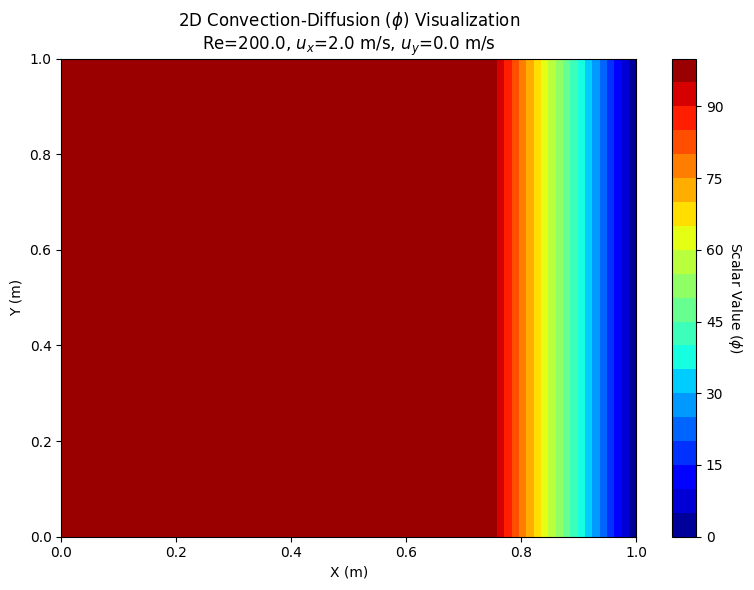

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# ... (Insert your complete code provided above here) ...

# =============================================================================
# Visualization
# =============================================================================

# Create meshgrid for plotting (assuming node-centered for simplicity here)
# Since nx=5, and Lx=1.0, nodes are at [0.0, 0.25, 0.5, 0.75, 1.0]
x = np.linspace(0, Lx, nx)
y = np.linspace(0, Ly, ny)
X, Y = np.meshgrid(x, y)

# Need to transpose 'phi' because matplotlib expects [row, col] -> (y, x)
# Your phi is indexed phi[i, j] representing (x_i, y_j)
plt.figure(figsize=(8, 6))

# Plot contours with filled color
# levels defines how many color bands to show
contour = plt.contourf(X, Y, phi.T, cmap='jet', levels=20) 

# Add a colorbar indicating scale
cbar = plt.colorbar(contour)
cbar.set_label('Scalar Value ($\phi$)', rotation=270, labelpad=15)

# Labels and Title
plt.xlabel('X (m)')
plt.ylabel('Y (m)')
plt.title(f'2D Convection-Diffusion ($\phi$) Visualization\n'
          f'Re={u*Lx/Gamma:.1f}, $u_x$={u:.1f} m/s, $u_y$={v:.1f} m/s')

plt.tight_layout()
plt.show()

## Jacobi Method

In [9]:
import numpy as np
""" 
25x1 + 2x2 + 2x3 = 12.6

3x1 + 27x2 + x3 = 14.3

2x1 + 3x2 + 17x3 = 6.0
"""

A = np.array([[25, 2, 2],
              [3, 27, 1],
              [2,  3, 17]], dtype=float)
B = np.array([12.6, 14.3, 6.0])

X = np.zeros(3)

tol = 0.01

for iteration in range(1,1000):
    X_new = X.copy()

    for i in range(0,len(X)):
        bi = B[i]
        aii = A[i,i]
        off_diagonal_sum = np.sum([A[i,j]*X[j] for j in range(len(X)) if i!=j])
        X_new[i] = (bi - off_diagonal_sum) / aii

    if np.max(np.abs(X_new - X)) < tol:
        print(f"Converged after {iteration} iterations")
        break

    X = X_new

print(f"Solution: x1={X[0]:.4f}, x2={X[1]:.4f}, x3={X[2]:.4f}")


Converged after 4 iterations
Solution: x1=0.4511, x2=0.4741, x3=0.2207


## Gauss Seidal

In [11]:
import numpy as np

A = np.array([[25, 2, 2],
              [3, 27, 1],
              [2,  3, 17]], dtype=float)
B = np.array([12.6, 14.3, 6.0])

X = np.zeros(3)
tol = 0.001
max_iter = 100

for iteration in range(1, max_iter):
    X_old = X.copy() # Store old values only to check convergence
    
    for i in range(len(B)):
        # Calculate the sum of A[i, j] * X[j] for all j != i
        # Since we update X[i] in-place, values for j < i are already 'new'
        row_sum = np.dot(A[i, :], X) - A[i, i] * X[i]
        
        # Update X[i] immediately
        X[i] = (B[i] - row_sum) / A[i, i]

    # Use the infinity norm (max absolute difference) to check convergence
    if np.linalg.norm(X - X_old, ord=np.inf) < tol:
        print(f"Converged after {iteration} iterations")
        break

print(f"Solution: x1={X[0]:.4f}, x2={X[1]:.4f}, x3={X[2]:.4f}")

Converged after 3 iterations
Solution: x1=0.4489, x2=0.4717, x3=0.2169


## SOR
- w<1 Used when the Gauss-Seidel method diverges. It makes the steps smaller and more conservative to ensure stability.
- w=0 (gauss-seidal)
- w>1<2 Used to accelerate convergence. It "overshoots" the Gauss-Seidel step to reach the solution faster. This is the typical range for SOR.
- w>2<0 Divergence
- $\omega_{opt} = \frac{2}{1 + \sqrt{1 - \rho(T_j)^2}}$
-  spectral radius $\rho$ of the Jacobi iteration matrix ($T_j$):

### Solution of Non-Linear Systems
- Fixed point Method
    - The strategy here is to transform your equation $f(x) = 0$ into the form $x = g(x)$. You then start with a guess $x_0$ and keep plugging the result back into the function: $x_{n+1} = g(x_n)$.
- Newton-Rapson Method
    - $$x_{n+1} = x_n - \frac{f(x_n)}{f'(x_n)}$$

## Solution of Ordinary Differential Equations
- Difference Method
- Euler's Method
- Modified Eulers Method
- RK-2
- RK-4 

### Curve Fittings
- Least Squares Regression (The Statistician's Choice)
- Newton Difference
- Bézier Curve
- B-Splines

### Solution of Partial DIfferential Equations
- Finite Difference Method
- Finite Element Method